In [1]:
!pip install tf_keras

In [2]:
#bibliotecas e importaçoes
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow
import zipfile
import itertools
import tf_keras as keras
from tensorflow.keras.preprocessing.image import img_to_array
from tensorflow.keras.models import load_model, model_from_json
from sklearn.metrics import confusion_matrix

In [3]:
%tensorflow_version 2.x
#confirmando a versao
import tensorflow
tensorflow.__version__

Colab only includes TensorFlow 2.x; %tensorflow_version has no effect.


'2.20.0'

In [4]:
# montado o gogle drive
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [5]:
# extrai o material principal
path = "/content/gdrive/My Drive/Material.zip"
zip_object = zipfile.ZipFile(file=path, mode="r")
zip_object.extractall('./')
zip_object.close()

# extrai o dataset com as imagens de treinamento
base_imgs = 'Material/fer2013.zip'
zip_object = zipfile.ZipFile(file=base_imgs, mode='r')
zip_object.extractall('./')
zip_object.close()

In [6]:
data = pd.read_csv('fer2013/fer2013.csv') # carrega o dataset com as imagens e emoções

print(f'{len(data)}') # mostra quantas imagens existem no total
print(f'{data.columns.tolist()}') # mostra as colunas do dataframe
data.tail() # exibe as últimas linhas para verificar a estrutura

35887
['emotion', 'pixels', 'Usage']


,emotion,pixels,Usage
35882,6,50 36 17 22 23 29 33 39 34 37 37 37 39 43 48 5...,PrivateTest
35883,3,178 174 172 173 181 188 191 194 196 199 200 20...,PrivateTest
35884,0,17 17 16 23 28 22 19 17 25 26 20 24 31 19 27 9...,PrivateTest
35885,3,30 28 28 29 31 30 42 68 79 81 77 67 67 71 63 6...,PrivateTest
35886,2,19 13 14 12 13 16 21 33 50 57 71 84 97 108 122...,PrivateTest


In [7]:
expressoes = ["Raiva", "Nojo", "Medo", "Feliz", "Triste", "Surpreso", "Neutro"] # nomes das emoções

In [8]:
pixels = data['pixels'].tolist() # converte a coluna de pixels para lista

largura, altura = 48, 48 # tamanho padrão que o modelo espera
faces = []
amostras = 0

for pixel_sequence in pixels:
    face = [int(pixel) for pixel in pixel_sequence.split(' ')] # converte string de pixels em lista
    face = np.asarray(face).reshape(largura, altura) # transforma em matriz
    faces.append(face)

In [9]:
faces = np.asarray(faces) # converte lista para array numpy
faces = np.expand_dims(faces, -1) # adiciona canal de cor

def normalizar(x):
    x = x.astype('float32') # converte os valores para float
    x = x / 255.0 # coloca os pixels no intervalo 0 a 1
    return x

faces = normalizar(faces) # aplica normalização

emocoes = pd.get_dummies(data['emotion']).values # converte os rótulos
print(f'{faces.shape}')
print(f'{emocoes.shape}')

(35887, 48, 48, 1)
(35887, 7)


In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(faces, emocoes, test_size=0.1, random_state=42)
_, X_val, _, y_val = train_test_split(X_train, y_train, test_size=0.1, random_state=41)

print(f'treino: {len(X_train)}')
print(f'validação: {len(X_val)} ')
print(f'teste: {len(X_test)}')

treino: 32298
validação: 3230 
teste: 3589


In [11]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D, BatchNormalization, Activation
from tensorflow.keras.losses import categorical_crossentropy
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint

num_features = 64 # número base de filtros
num_labels = 7 # 7 emoções possíveis na saída
batch_size = 64
epochs = 100
width, height = 48, 48

model = Sequential()

# extrai bordas e texturas simples
model.add(Conv2D(num_features, kernel_size=(3,3), activation='relu',
                 input_shape=(width, height, 1), data_format='channels_last',
                 kernel_regularizer=l2(0.01)))
model.add(Conv2D(num_features, kernel_size=(3,3), activation='relu', padding='same'))
model.add(BatchNormalization()) # normaliza as ativações pra estabilizar
model.add(MaxPooling2D(pool_size=(2,2), strides=(2,2))) # reduz pela metade
model.add(Dropout(0.5))

# extrai formas mais complexas com o dobro
model.add(Conv2D(2*num_features, kernel_size=(3,3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(Conv2D(2*num_features, kernel_size=(3,3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2), strides=(2,2)))
model.add(Dropout(0.5))

# padrões ainda mais abstratos
model.add(Conv2D(2*2*num_features, kernel_size=(3,3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(Conv2D(2*2*num_features, kernel_size=(3,3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2), strides=(2,2)))
model.add(Dropout(0.5))

# caracteristicas da expressão facial completa
model.add(Conv2D(2*2*2*num_features, kernel_size=(3,3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(Conv2D(2*2*2*num_features, kernel_size=(3,3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2), strides=(2,2)))
model.add(Dropout(0.5))

# Camadas densas
model.add(Flatten()) # transforma em vetor 1D

model.add(Dense(2*2*2*num_features, activation='relu'))
model.add(Dropout(0.4))
model.add(Dense(2*2*num_features, activation='relu'))
model.add(Dropout(0.4))
model.add(Dense(2*num_features, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(num_labels, activation='softmax')) # converte pra probabilidade

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 46, 46, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 46, 46, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 46, 46, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 23, 23, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 23, 23, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 23, 23, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 23, 23, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 11, 11, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 11, 11, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 11, 11, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 11, 11, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 11, 11, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 11, 11, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 5, 5, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 5, 5, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 5, 5, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 5, 5, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 5,905,863 (22.53 MB)

 Trainable params: 5,902,151 (22.51 MB)

 Non-trainable params: 3,712 (14.50 KB)

In [12]:
arquivo_modelo = 'modelo_01_expressoes.h5'
arquivo_modelo_json = 'modelo_01_expressoes.json'

model.compile(
    loss='categorical_crossentropy', # perda padrão pra classificação
    optimizer=Adam(learning_rate=0.001, beta_1=0.9, beta_2=0.999, epsilon=1e-7),
    metrics=['accuracy']
)

# reduz o learning rate
lr_reducer = ReduceLROnPlateau(monitor='val_loss', factor=0.9, patience=3, verbose=1)

# para o treino se não melhorar por 8 épocas
early_stopper = EarlyStopping(monitor='val_loss', min_delta=0, patience=8, verbose=1, mode='auto')

# salva automaticamente o melhor modelo
checkpointer = ModelCheckpoint(arquivo_modelo, monitor='val_loss', verbose=1, save_best_only=True)

# salva a arquitetura em JSON separado dos pesos
model_json = model.to_json()
with open(arquivo_modelo_json, 'w') as json_file:
    json_file.write(model_json)

In [13]:
# treinar o modelo
history = model.fit(
    np.array(X_train), np.array(y_train),
    batch_size=batch_size,
    epochs=epochs,
    verbose=1,
    validation_data=(np.array(X_val), np.array(y_val)),
    shuffle=True,
    callbacks=[lr_reducer, early_stopper, checkpointer]
)

Epoch 1/100
505/505 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.2073 - loss: 2.2593
Epoch 1: val_loss improved from None to 1.82243, saving model to modelo_01_expressoes.h5



Epoch 1: finished saving model to modelo_01_expressoes.h5
505/505 ━━━━━━━━━━━━━━━━━━━━ 63s 80ms/step - accuracy: 0.2235 - loss: 1.9733 - val_accuracy: 0.2594 - val_loss: 1.8224 - learning_rate: 0.0010
Epoch 2/100
505/505 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.2420 - loss: 1.8385
Epoch 2: val_loss improved from 1.82243 to 1.78883, saving model to modelo_01_expressoes.h5



Epoch 2: finished saving model to modelo_01_expressoes.h5
505/505 ━━━━━━━━━━━━━━━━━━━━ 24s 47ms/step - accuracy: 0.2478 - loss: 1.8298 - val_accuracy: 0.2598 - val_loss: 1.7888 - learning_rate: 0.0010
Epoch 3/100
505/505 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.2508 - loss: 1.8170
Epoch 3: val_loss did not improve from 1.78883
505/505 ━━━━━━━━━━━━━━━━━━━━ 24s 47ms/step - accuracy: 0.2540 - loss: 1.8112 - val_accuracy: 0.2598 - val_loss: 1.8363 - learning_rate: 0.0010
Epoch 4/100
504/505 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.2825 - loss: 1.7637
Epoch 4: val_loss improved from 1.78883 to 1.65789, saving model to modelo_01_expressoes.h5



Epoch 4: finished saving model to modelo_01_expressoes.h5
505/505 ━━━━━━━━━━━━━━━━━━━━ 25s 49ms/step - accuracy: 0.2967 - loss: 1.7321 - val_accuracy: 0.3207 - val_loss: 1.6579 - learning_rate: 0.0010
Epoch 5/100
505/505 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.3496 - loss: 1.6314
Epoch 5: val_loss did not improve from 1.65789
505/505 ━━━━━━━━━━━━━━━━━━━━ 25s 50ms/step - accuracy: 0.3598 - loss: 1.6127 - val_accuracy: 0.3019 - val_loss: 1.7436 - learning_rate: 0.0010
Epoch 6/100
504/505 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.3903 - loss: 1.5434
Epoch 6: val_loss improved from 1.65789 to 1.55688, saving model to modelo_01_expressoes.h5



Epoch 6: finished saving model to modelo_01_expressoes.h5
505/505 ━━━━━━━━━━━━━━━━━━━━ 25s 49ms/step - accuracy: 0.4007 - loss: 1.5208 - val_accuracy: 0.3833 - val_loss: 1.5569 - learning_rate: 0.0010
Epoch 7/100
505/505 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.4207 - loss: 1.4692
Epoch 7: val_loss improved from 1.55688 to 1.48456, saving model to modelo_01_expressoes.h5


...


Epoch 89: finished saving model to modelo_01_expressoes.h5
505/505 ━━━━━━━━━━━━━━━━━━━━ 25s 49ms/step - accuracy: 0.9031 - loss: 0.3001 - val_accuracy: 0.9842 - val_loss: 0.0707 - learning_rate: 6.5610e-04
Epoch 90/100
504/505 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.9069 - loss: 0.2940
Epoch 90: val_loss did not improve from 0.07065
505/505 ━━━━━━━━━━━━━━━━━━━━ 25s 49ms/step - accuracy: 0.9046 - loss: 0.2955 - val_accuracy: 0.9824 - val_loss: 0.0762 - learning_rate: 6.5610e-04
Epoch 91/100
505/505 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.9079 - loss: 0.2892
Epoch 91: val_loss did not improve from 0.07065
505/505 ━━━━━━━━━━━━━━━━━━━━ 25s 49ms/step - accuracy: 0.9060 - loss: 0.2928 - val_accuracy: 0.9743 - val_loss: 0.0904 - learning_rate: 6.5610e-04
Epoch 92/100
505/505 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.9081 - loss: 0.2850
Epoch 92: ReduceLROnPlateau reducing learning rate to 0.0005904900433961303.

Epoch 92: val_loss did not improve from 0.07065
505/505 ━━


Epoch 93: finished saving model to modelo_01_expressoes.h5
505/505 ━━━━━━━━━━━━━━━━━━━━ 25s 49ms/step - accuracy: 0.9081 - loss: 0.2824 - val_accuracy: 0.9851 - val_loss: 0.0639 - learning_rate: 5.9049e-04
Epoch 94/100
504/505 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.9083 - loss: 0.2799
Epoch 94: val_loss did not improve from 0.06385
505/505 ━━━━━━━━━━━━━━━━━━━━ 25s 49ms/step - accuracy: 0.9114 - loss: 0.2739 - val_accuracy: 0.9839 - val_loss: 0.0662 - learning_rate: 5.9049e-04
Epoch 95/100
504/505 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.9141 - loss: 0.2667
Epoch 95: val_loss improved from 0.06385 to 0.06352, saving model to modelo_01_expressoes.h5



Epoch 95: finished saving model to modelo_01_expressoes.h5
505/505 ━━━━━━━━━━━━━━━━━━━━ 25s 49ms/step - accuracy: 0.9124 - loss: 0.2709 - val_accuracy: 0.9814 - val_loss: 0.0635 - learning_rate: 5.9049e-04
Epoch 96/100
505/505 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.9160 - loss: 0.2576
Epoch 96: val_loss did not improve from 0.06352
505/505 ━━━━━━━━━━━━━━━━━━━━ 25s 49ms/step - accuracy: 0.9142 - loss: 0.2639 - val_accuracy: 0.9839 - val_loss: 0.0644 - learning_rate: 5.9049e-04
Epoch 97/100
504/505 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.9146 - loss: 0.2655
Epoch 97: val_loss improved from 0.06352 to 0.05405, saving model to modelo_01_expressoes.h5



Epoch 97: finished saving model to modelo_01_expressoes.h5
505/505 ━━━━━━━━━━━━━━━━━━━━ 25s 49ms/step - accuracy: 0.9161 - loss: 0.2592 - val_accuracy: 0.9898 - val_loss: 0.0540 - learning_rate: 5.9049e-04
Epoch 98/100
504/505 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.9174 - loss: 0.2555
Epoch 98: val_loss improved from 0.05405 to 0.05079, saving model to modelo_01_expressoes.h5



Epoch 98: finished saving model to modelo_01_expressoes.h5
505/505 ━━━━━━━━━━━━━━━━━━━━ 25s 49ms/step - accuracy: 0.9172 - loss: 0.2579 - val_accuracy: 0.9895 - val_loss: 0.0508 - learning_rate: 5.9049e-04
Epoch 99/100
504/505 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.9193 - loss: 0.2487
Epoch 99: val_loss did not improve from 0.05079
505/505 ━━━━━━━━━━━━━━━━━━━━ 25s 49ms/step - accuracy: 0.9202 - loss: 0.2526 - val_accuracy: 0.9827 - val_loss: 0.0701 - learning_rate: 5.9049e-04
Epoch 100/100
505/505 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.9215 - loss: 0.2442
Epoch 100: val_loss did not improve from 0.05079
505/505 ━━━━━━━━━━━━━━━━━━━━ 25s 49ms/step - accuracy: 0.9189 - loss: 0.2479 - val_accuracy: 0.9873 - val_loss: 0.0520 - learning_rate: 5.9049e-04


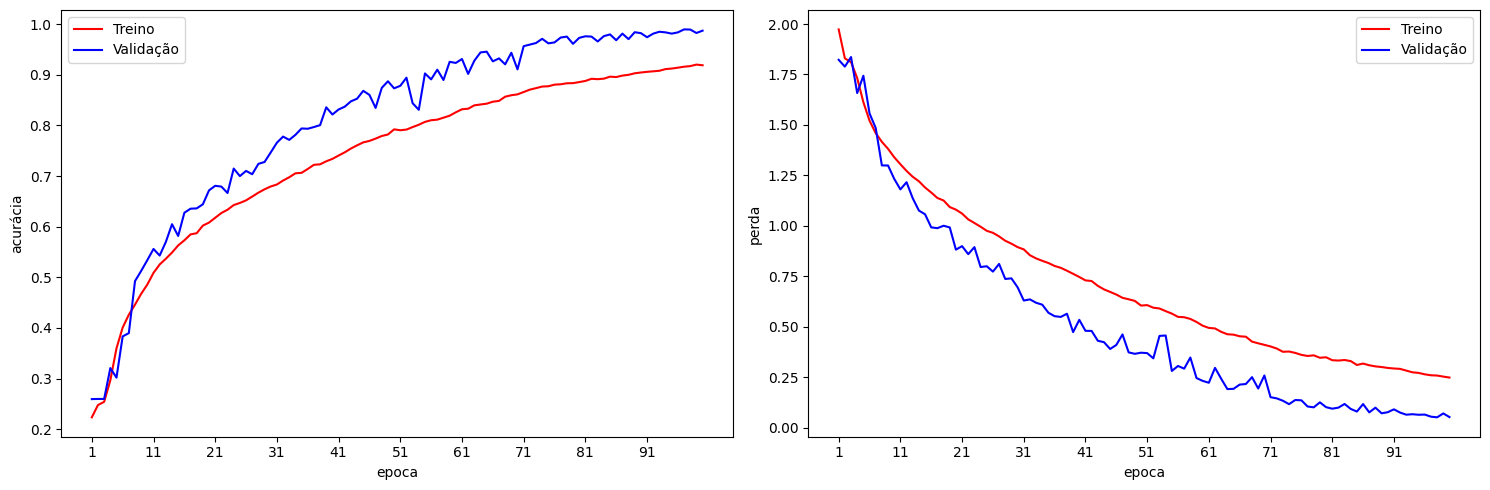

In [15]:
def plota_historico_modelo(historico_modelo):
    fig, axs = plt.subplots(1, 2, figsize=(15, 5))
    num_epochs = len(historico_modelo.history['accuracy'])
    tick_interval = max(1, num_epochs // 10)

    # gráfico de acurácia
    axs[0].plot(range(1, num_epochs + 1), historico_modelo.history['accuracy'], 'r', label='Treino')
    axs[0].plot(range(1, num_epochs + 1), historico_modelo.history['val_accuracy'], 'b', label='Validação')
    axs[0].set_ylabel('acurácia')
    axs[0].set_xlabel('epoca')
    axs[0].set_xticks(np.arange(1, num_epochs + 1, tick_interval))
    axs[0].legend(loc='best')

    # gráfico de perda
    axs[1].plot(range(1, num_epochs + 1), historico_modelo.history['loss'], 'r', label='Treino')
    axs[1].plot(range(1, num_epochs + 1), historico_modelo.history['val_loss'], 'b', label='Validação')
    axs[1].set_ylabel('perda')
    axs[1].set_xlabel('epoca')
    axs[1].set_xticks(np.arange(1, num_epochs + 1, tick_interval))
    axs[1].legend(loc='best')

    plt.tight_layout()
    plt.show()

plota_historico_modelo(history)

In [17]:
scores = model.evaluate(np.array(X_test), np.array(y_test), batch_size=batch_size)
print(f'acurácia no teste: {scores[1]*100:.2f}%')
print(f'perda no teste: {scores[0]:.4f}')

57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.6673 - loss: 1.7078
acurácia no teste: 66.73%
perda no teste: 1.7078


113/113 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step


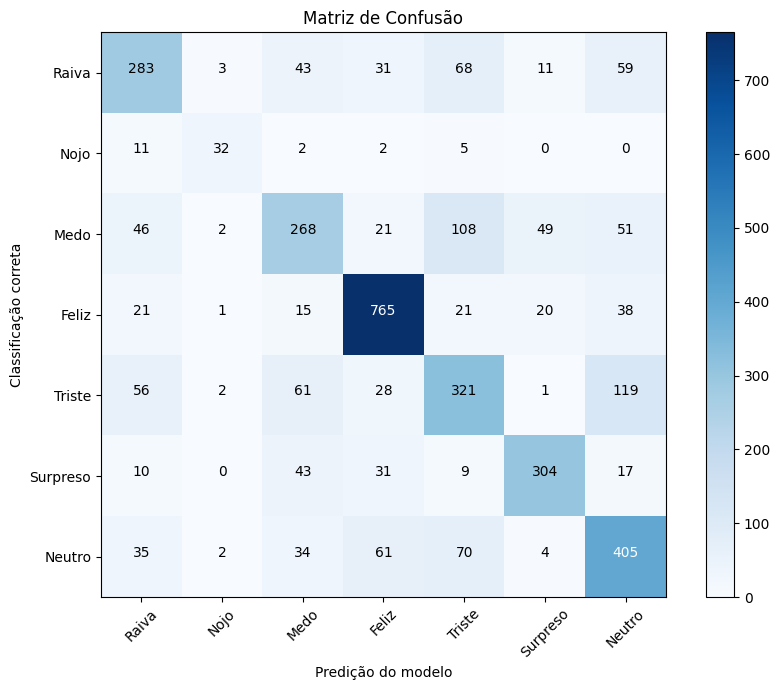

In [18]:
# carrega o melhor modelo
json_file = open(arquivo_modelo_json, 'r')
loaded_model_json = json_file.read()
json_file.close()
loaded_model = model_from_json(loaded_model_json)
loaded_model.load_weights(arquivo_modelo)

# gera as previsões no conjunto
y_pred = loaded_model.predict(X_test)

true_y = [np.argmax(y) for y in y_test.tolist()] # índice da emoção real
pred_y = [np.argmax(y) for y in y_pred.tolist()] # índice da emoção prevista

np.save('truey_mod01', true_y)
np.save('predy_mod01', pred_y)

# plota a matriz
cm = confusion_matrix(true_y, pred_y)
titulo = 'Matriz de Confusão'

plt.figure(figsize=(9, 7))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title(titulo)
plt.colorbar()
tick_marks = np.arange(len(expressoes))
plt.xticks(tick_marks, expressoes, rotation=45)
plt.yticks(tick_marks, expressoes)

thresh = cm.max() / 2.
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, format(cm[i, j], 'd'),
             horizontalalignment='center',
             color='white' if cm[i, j] > thresh else 'black')

plt.ylabel('Classificação correta')
plt.xlabel('Predição do modelo')
plt.tight_layout()
plt.savefig('matriz_confusao_mod01.png')
plt.show()

In [20]:
# analisa quais emoções
acertos_por_emocao = cm.diagonal()
total_por_emocao = cm.sum(axis=1)
acuracia_por_emocao = acertos_por_emocao / total_por_emocao * 100

for emocao, acc in zip(expressoes, acuracia_por_emocao):
    print(f'{emocao}: {acc:.1f}% de acerto')

melhor = expressoes[np.argmax(acuracia_por_emocao)]
pior = expressoes[np.argmin(acuracia_por_emocao)]
print(f'\nmelhor emoção: {melhor}')
print(f'pior emoção: {pior}')

Raiva: 56.8% de acerto
Nojo: 61.5% de acerto
Medo: 49.2% de acerto
Feliz: 86.8% de acerto
Triste: 54.6% de acerto
Surpreso: 73.4% de acerto
Neutro: 66.3% de acerto

melhor emoção: Feliz
pior emoção: Medo


1


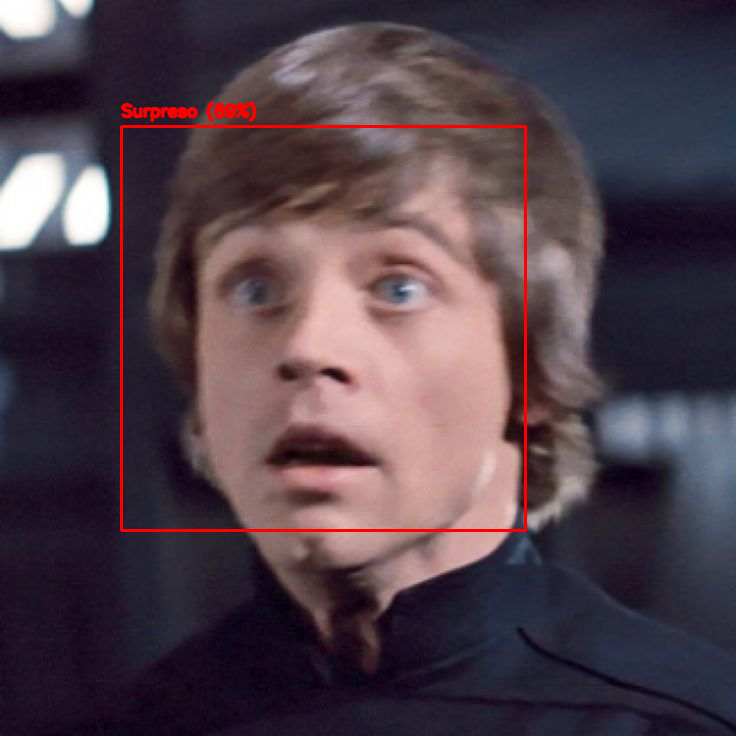

1


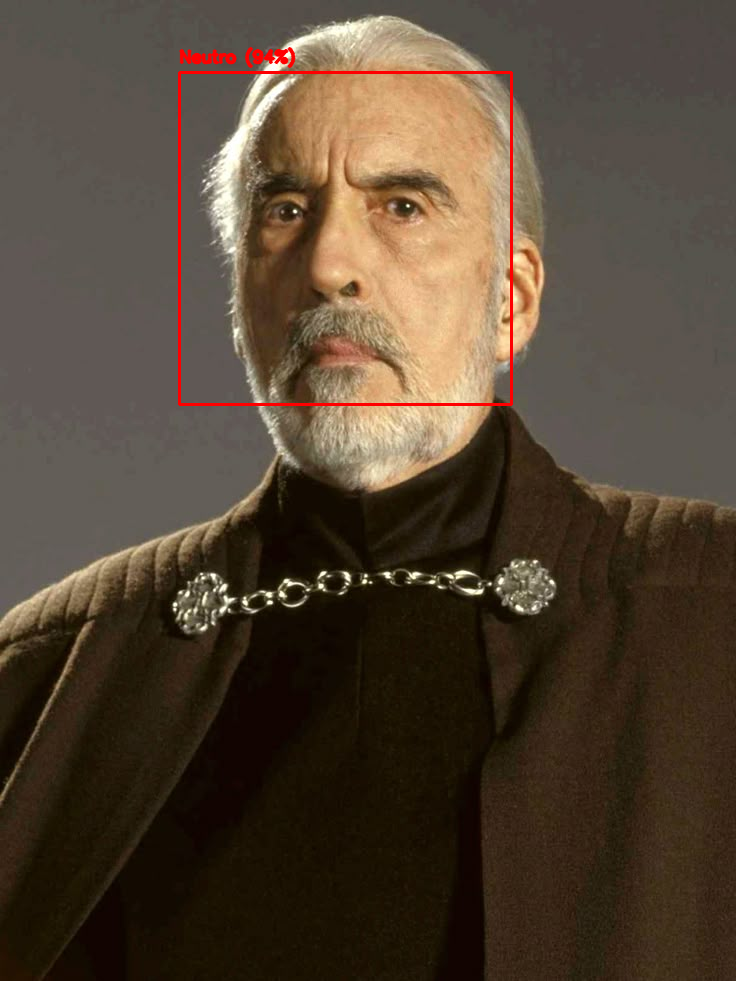

1


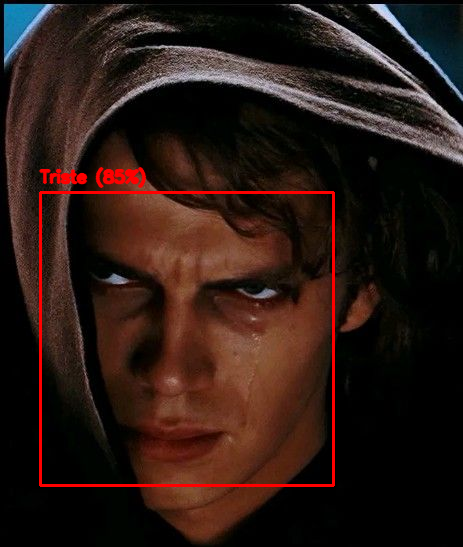

1


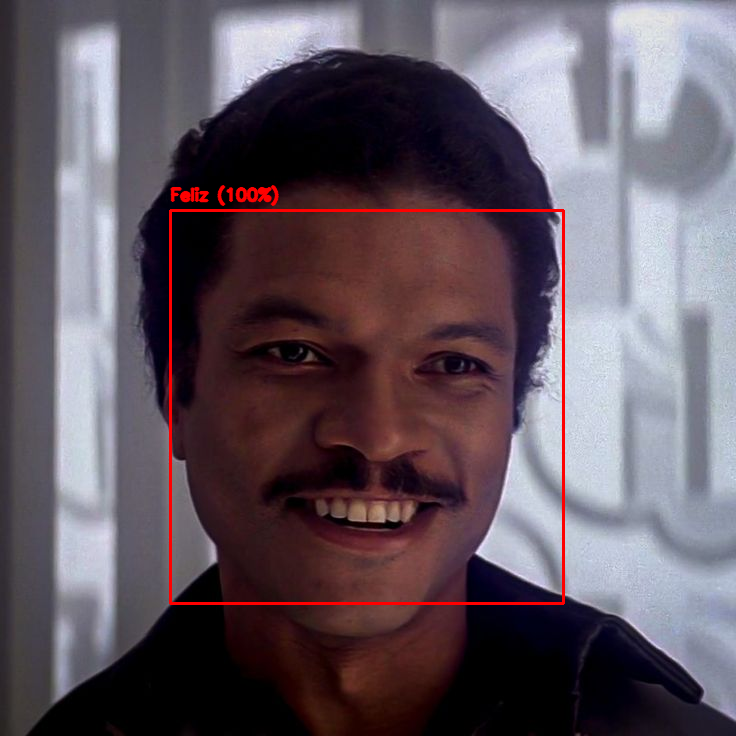

In [28]:
import os

# pasta de imagen
pasta = '/content/Imagen'

arquivos = [f for f in os.listdir(pasta) if f.endswith(('.jpeg'))]
face_cascade = cv2.CascadeClassifier('Material/haarcascade_frontalface_default.xml')

for arquivo in arquivos:

    caminho = os.path.join(pasta, arquivo)
    img = cv2.imread(caminho)


    img_original = img.copy()
    cinza = cv2.cvtColor(img_original, cv2.COLOR_BGR2GRAY) # converte pra cinza

    faces_encontradas = face_cascade.detectMultiScale(
        cinza,
        scaleFactor=1.1,
        minNeighbors=10, # mais rigoroso pra evitar
        minSize=(60, 60)
    )

    print(f'{len(faces_encontradas)}')

    for (x, y, w, h) in faces_encontradas:
        roi = cinza[y:y + h, x:x + w]
        roi = roi.astype('float') / 255.0
        roi = np.expand_dims(np.expand_dims(cv2.resize(roi, (48, 48)), -1), 0)

        preds = loaded_model.predict(roi, verbose=0)[0]
        confianca = np.max(preds)

        if confianca > 0.50:
            label = expressoes[np.argmax(preds)]
            cv2.putText(img_original, f'{label} ({confianca*100:.0f}%)', (x, y - 10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.55, (0, 0, 255), 2, cv2.LINE_AA)
            cv2.rectangle(img_original, (x, y), (x + w, y + h), (0, 0, 255), 2)

    cv2_imshow(img_original)